## Loading and Inspect Data



In [44]:
from google.colab import files
uploades = files.upload()
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

spark = SparkSession.builder.appName("CSV").getOrCreate()

df = spark.read.csv("/content/Railway_info.csv",
                    header = True,
                    inferSchema = True
)

df.show()


Saving Railway_info.csv to Railway_info (1).csv
+--------+----------------+--------------------+------------------------+---------+
|Train_No|      Train_Name| Source_Station_Name|Destination_Station_Name|     days|
+--------+----------------+--------------------+------------------------+---------+
|     107|    SWV-MAO-VLNK|     SAWANTWADI ROAD|             MADGOAN JN.| Saturday|
|     108|    VLNK-MAO-SWV|         MADGOAN JN.|         SAWANTWADI ROAD|   Friday|
|     128|    MAO-KOP SPEC|         MADGOAN JN.|    CHHATRAPATI SHAHU...|   Friday|
|     290|    PALACE ON WH|   DELHI-SAFDAR JANG|       DELHI-SAFDAR JANG|Wednesday|
|     401|    BSB BHARATDA|          AURANGABAD|            VARANASI JN.| Saturday|
|     421|    LKO-SVDK FTR|         LUCKNOW JN.|    SHRI MATA VAISHNO...|  Tuesday|
|     422|    SVDK-LKO FTR|SHRI MATA VAISHNO...|             LUCKNOW JN.|   Monday|
|     477|    FTR TRAIN NO|               SIRSA|                   SIRSA|   Sunday|
|     502|    RJPB-UMB FTR|R

In [45]:
#first 10 rows in csv file
df.show(10)

+--------+------------+--------------------+------------------------+---------+
|Train_No|  Train_Name| Source_Station_Name|Destination_Station_Name|     days|
+--------+------------+--------------------+------------------------+---------+
|     107|SWV-MAO-VLNK|     SAWANTWADI ROAD|             MADGOAN JN.| Saturday|
|     108|VLNK-MAO-SWV|         MADGOAN JN.|         SAWANTWADI ROAD|   Friday|
|     128|MAO-KOP SPEC|         MADGOAN JN.|    CHHATRAPATI SHAHU...|   Friday|
|     290|PALACE ON WH|   DELHI-SAFDAR JANG|       DELHI-SAFDAR JANG|Wednesday|
|     401|BSB BHARATDA|          AURANGABAD|            VARANASI JN.| Saturday|
|     421|LKO-SVDK FTR|         LUCKNOW JN.|    SHRI MATA VAISHNO...|  Tuesday|
|     422|SVDK-LKO FTR|SHRI MATA VAISHNO...|             LUCKNOW JN.|   Monday|
|     477|FTR TRAIN NO|               SIRSA|                   SIRSA|   Sunday|
|     502|RJPB-UMB FTR|RAJENDRANAGAR TER...|         AMBALA CANTT JN|   Monday|
|     504|PNBE-BTI FTR|           PATNA 

In [46]:
#data types in csv file
df.printSchema()

root
 |-- Train_No: integer (nullable = true)
 |-- Train_Name: string (nullable = true)
 |-- Source_Station_Name: string (nullable = true)
 |-- Destination_Station_Name: string (nullable = true)
 |-- days: string (nullable = true)



# Basics Statics

In [47]:
df.count()

11113

In [48]:
df.select("Source_Station_Name").distinct().count()

921

In [49]:
df.select("Destination_Station_Name").distinct().count()

924

In [50]:
df.groupBy("Source_Station_Name").count().orderBy("count",ascending=False).show()

+--------------------+-----+
| Source_Station_Name|count|
+--------------------+-----+
|          CST-MUMBAI|  513|
|             SEALDAH|  372|
|       CHENNAI BEACH|  339|
|          HOWRAH JN.|  338|
|           KALYAN JN|  285|
|               THANE|  186|
|              PANVEL|  141|
|            TAMBARAM|  140|
|         MOOR MARKET|  135|
|          VELACHEERY|  115|
|           NEW DELHI|  107|
|            RAVLI JN|   99|
|               VASHI|   92|
|           DELHI JN.|   88|
|            PUNE JN.|   81|
|     CHENNAI CENTRAL|   78|
|      BARDDHAMAN JN.|   78|
|        CHENGALPATTU|   74|
|          BANDEL JN.|   73|
|LOKMANYA TILAK TE...|   70|
+--------------------+-----+
only showing top 20 rows


# Data Cleaning

In [51]:
#missing values
df.select([count(when(col(c).isNull(),c)).alias(c) for c in df.columns]).show()

+--------+----------+-------------------+------------------------+----+
|Train_No|Train_Name|Source_Station_Name|Destination_Station_Name|days|
+--------+----------+-------------------+------------------------+----+
|       0|         0|                  0|                       0|   0|
+--------+----------+-------------------+------------------------+----+



In [52]:
df1=df.dropna().show()

+--------+----------------+--------------------+------------------------+---------+
|Train_No|      Train_Name| Source_Station_Name|Destination_Station_Name|     days|
+--------+----------------+--------------------+------------------------+---------+
|     107|    SWV-MAO-VLNK|     SAWANTWADI ROAD|             MADGOAN JN.| Saturday|
|     108|    VLNK-MAO-SWV|         MADGOAN JN.|         SAWANTWADI ROAD|   Friday|
|     128|    MAO-KOP SPEC|         MADGOAN JN.|    CHHATRAPATI SHAHU...|   Friday|
|     290|    PALACE ON WH|   DELHI-SAFDAR JANG|       DELHI-SAFDAR JANG|Wednesday|
|     401|    BSB BHARATDA|          AURANGABAD|            VARANASI JN.| Saturday|
|     421|    LKO-SVDK FTR|         LUCKNOW JN.|    SHRI MATA VAISHNO...|  Tuesday|
|     422|    SVDK-LKO FTR|SHRI MATA VAISHNO...|             LUCKNOW JN.|   Monday|
|     477|    FTR TRAIN NO|               SIRSA|                   SIRSA|   Sunday|
|     502|    RJPB-UMB FTR|RAJENDRANAGAR TER...|         AMBALA CANTT JN|   

In [53]:
#making all names into uppercase
df.withColumn("Source_Station_Name",upper(col("Source_Station_Name")))
df.show(5)

+--------+------------+-------------------+------------------------+---------+
|Train_No|  Train_Name|Source_Station_Name|Destination_Station_Name|     days|
+--------+------------+-------------------+------------------------+---------+
|     107|SWV-MAO-VLNK|    SAWANTWADI ROAD|             MADGOAN JN.| Saturday|
|     108|VLNK-MAO-SWV|        MADGOAN JN.|         SAWANTWADI ROAD|   Friday|
|     128|MAO-KOP SPEC|        MADGOAN JN.|    CHHATRAPATI SHAHU...|   Friday|
|     290|PALACE ON WH|  DELHI-SAFDAR JANG|       DELHI-SAFDAR JANG|Wednesday|
|     401|BSB BHARATDA|         AURANGABAD|            VARANASI JN.| Saturday|
+--------+------------+-------------------+------------------------+---------+
only showing top 5 rows


In [54]:
df1=df.withColumn("Source_Station_Name",
                 upper(col("Source_Station_Name")))
df1.show()

+--------+----------------+--------------------+------------------------+---------+
|Train_No|      Train_Name| Source_Station_Name|Destination_Station_Name|     days|
+--------+----------------+--------------------+------------------------+---------+
|     107|    SWV-MAO-VLNK|     SAWANTWADI ROAD|             MADGOAN JN.| Saturday|
|     108|    VLNK-MAO-SWV|         MADGOAN JN.|         SAWANTWADI ROAD|   Friday|
|     128|    MAO-KOP SPEC|         MADGOAN JN.|    CHHATRAPATI SHAHU...|   Friday|
|     290|    PALACE ON WH|   DELHI-SAFDAR JANG|       DELHI-SAFDAR JANG|Wednesday|
|     401|    BSB BHARATDA|          AURANGABAD|            VARANASI JN.| Saturday|
|     421|    LKO-SVDK FTR|         LUCKNOW JN.|    SHRI MATA VAISHNO...|  Tuesday|
|     422|    SVDK-LKO FTR|SHRI MATA VAISHNO...|             LUCKNOW JN.|   Monday|
|     477|    FTR TRAIN NO|               SIRSA|                   SIRSA|   Sunday|
|     502|    RJPB-UMB FTR|RAJENDRANAGAR TER...|         AMBALA CANTT JN|   

# LEVEL 2
# DATA TRANSFORMATION AND AGGREGATION

2.1 : Data Filtering


In [55]:
#saturdat trains
saturday = df.filter(df["days"]=="Saturday")
saturday.show()

+--------+------------+--------------------+------------------------+--------+
|Train_No|  Train_Name| Source_Station_Name|Destination_Station_Name|    days|
+--------+------------+--------------------+------------------------+--------+
|     107|SWV-MAO-VLNK|     SAWANTWADI ROAD|             MADGOAN JN.|Saturday|
|     401|BSB BHARATDA|          AURANGABAD|            VARANASI JN.|Saturday|
|    1196|NGP-KRMI SPL|      NAGPUR JN.(CR)|                 KARMALI|Saturday|
|    1706| JBP-BDTS SF|            JABALPUR|         BANDRA TERMINUS|Saturday|
|    2834|SRC-RJT SF A|     SANTRAGACHI JN.|                  RAJKOT|Saturday|
|    3305| DHN-KUSUNDA|         DHANBAD JN.|                 KUSUNDA|Saturday|
|    3502|ANVT-JSME BI|ANAND VIHAR TERMINAL|             JASIDIH JN.|Saturday|
|    4802|MKN PBC PASS|         MAKRANA JN.|          PARVATSAR CITY|Saturday|
|    5066| LJN-CPR-EXP|         LUCKNOW JN.|             CHHAPRA JN.|Saturday|
|    5306|FBD- CPA EXP|      FARRUKHABAD JN|        

In [56]:
#specific station
station = df.filter(df["Source_Station_Name"]=="CHENNAI CENTRAL")
station.show()

+--------+------------+-------------------+------------------------+---------+
|Train_No|  Train_Name|Source_Station_Name|Destination_Station_Name|     days|
+--------+------------+-------------------+------------------------+---------+
|    2842| MAS SRC SPL|    CHENNAI CENTRAL|         SANTRAGACHI JN.|Wednesday|
|    6041|MAS-QLN SPEC|    CHENNAI CENTRAL|                  QUILON|   Monday|
|    6043| MAS-QLN SPL|    CHENNAI CENTRAL|                  QUILON| Saturday|
|    6047| MAS-QLN SPL|    CHENNAI CENTRAL|                  QUILON|   Friday|
|    6058|MAS-SRC  EXP|    CHENNAI CENTRAL|         SANTRAGACHI JN.|  Tuesday|
|   11028|MAS-CSMT MUM|    CHENNAI CENTRAL|              CST-MUMBAI| Thursday|
|   11042|MAS-CSMT MUM|    CHENNAI CENTRAL|              CST-MUMBAI| Saturday|
|   11074|CHENNAI - LT|    CHENNAI CENTRAL|    LOKMANYA TILAK TE...|Wednesday|
|   12007|MAS-MYS SHAT|    CHENNAI CENTRAL|              MYSORE JN.|   Friday|
|   12027|MAS-SBC SHAT|    CHENNAI CENTRAL|    KRANT

2.2 : Grouping and Aggregation


In [57]:
#count the number of trains from each station
df.groupBy("Source_Station_Name").agg(count("*")).alias("TRAIN COUNT").show()

+-------------------+--------+
|Source_Station_Name|count(1)|
+-------------------+--------+
|       PILIBHIT JN.|      18|
|         JAKHAL JN.|       2|
|          BHILDI JN|       1|
|          INDORE BG|      41|
|            ARAMBAG|      13|
|            CHHEOKI|       1|
|        KASHIPUR JN|       5|
|     UDHAGAMANDALAM|       4|
|    AMBALA CANTT JN|      29|
|            MUNABAO|       2|
|   NARKATIAGANJ JN.|      12|
|      DHASA JN (MG)|       4|
|        BURHWAL JN.|       2|
|     SIMALUGURI JN.|       1|
| TRIVANDRUM CENTRAL|      35|
|    CHENNAI CENTRAL|      78|
|          DEHRA DUN|      19|
|           RAJMAHAL|       8|
|             BODHAN|       3|
|          JAISALMER|       8|
+-------------------+--------+
only showing top 20 rows


In [58]:
print(df.columns)

['Train_No', 'Train_Name', 'Source_Station_Name', 'Destination_Station_Name', 'days']


In [59]:
#average
df.groupBy("Source_Station_Name","days").count().show()

+-------------------+---------+-----+
|Source_Station_Name|     days|count|
+-------------------+---------+-----+
|       TATANAGAR JN|Wednesday|    5|
|        BATHINDA JN|   Sunday|    5|
|               OKHA|   Friday|    2|
|        KATIHAR JN.|   Sunday|    2|
|        MAILANI JN.|Thursdayd|    3|
|              DUMKA|   Friday|    2|
|        BATHINDA JN| Saturday|    1|
|           ADILABAD| Saturday|    1|
|              SURAT|   Monday|    1|
|     MERTA ROAD JN.|   Friday|    4|
|         SONPUR JN.|   Monday|    1|
|            DINHATA|Wednesday|    1|
|           DOMBIVLI|  Tuesday|    7|
|         VIDYAVIHAR| Thursday|    1|
|             RAMTEK|   Sunday|    1|
|               DURG|   Monday|    5|
|        KAZIPET JN.| Thursday|    2|
|       BAREILLY JN.|   Friday|    4|
|         KHAJAURAHO|  Tuesday|    2|
|       RANAGHAT JN.|  Tuesday|    3|
+-------------------+---------+-----+
only showing top 20 rows


In [60]:
print(type(df))

<class 'pyspark.sql.classic.dataframe.DataFrame'>


In [61]:
#Data Enrichment
df = df.withColumn("Category",when(df["days"].isin("Saturday","Sunday"),"Weekend").otherwise("Weekday"))
df.show()

+--------+----------------+--------------------+------------------------+---------+--------+
|Train_No|      Train_Name| Source_Station_Name|Destination_Station_Name|     days|Category|
+--------+----------------+--------------------+------------------------+---------+--------+
|     107|    SWV-MAO-VLNK|     SAWANTWADI ROAD|             MADGOAN JN.| Saturday| Weekend|
|     108|    VLNK-MAO-SWV|         MADGOAN JN.|         SAWANTWADI ROAD|   Friday| Weekday|
|     128|    MAO-KOP SPEC|         MADGOAN JN.|    CHHATRAPATI SHAHU...|   Friday| Weekday|
|     290|    PALACE ON WH|   DELHI-SAFDAR JANG|       DELHI-SAFDAR JANG|Wednesday| Weekday|
|     401|    BSB BHARATDA|          AURANGABAD|            VARANASI JN.| Saturday| Weekend|
|     421|    LKO-SVDK FTR|         LUCKNOW JN.|    SHRI MATA VAISHNO...|  Tuesday| Weekday|
|     422|    SVDK-LKO FTR|SHRI MATA VAISHNO...|             LUCKNOW JN.|   Monday| Weekday|
|     477|    FTR TRAIN NO|               SIRSA|                   SIR

# 3.1 : Advanced Data Analysis

In [86]:
#Pattern analysis
day_count = df.groupBy("days").count()
day_count.show()

+----------+-----+
|      days|count|
+----------+-----+
| Saturdayd|  152|
| Wednesday| 1448|
|   Tuesday| 1454|
|  Tuesdayd|  174|
|Wednesdayd|  164|
| Thursdayd|  154|
|    Friday| 1471|
|   Fridayd|  178|
|   Sundayd|  170|
|  Thursday| 1372|
|  Saturday| 1441|
|   Mondayd|  161|
|    Monday| 1342|
|    Sunday| 1432|
+----------+-----+



In [121]:
from pyspark.sql.functions import regexp_replace

df = df.withColumn("days", regexp_replace("days", "Mondayd", "Monday"))
df = df.withColumn("days", regexp_replace("days", "Tuesdayd", "Tuesday"))
df = df.withColumn("days", regexp_replace("days", "Wednesdayd", "Wednesday"))
df = df.withColumn("days", regexp_replace("days", "Thursdayd", "Thursday"))
df = df.withColumn("days", regexp_replace("days", "Fridayd", "Friday"))
df = df.withColumn("days", regexp_replace("days", "Saturdayd", "Saturday"))
df = df.withColumn("days", regexp_replace("days", "Sundayd", "Sunday"))

df.select("days").distinct().show(20, False)

df.show()

+---------+
|days     |
+---------+
|Wednesday|
|Tuesday  |
|Friday   |
|Thursday |
|Saturday |
|Monday   |
|Sunday   |
+---------+

+--------+----------------+--------------------+------------------------+---------+--------+
|Train_No|      Train_Name| Source_Station_Name|Destination_Station_Name|     days|Category|
+--------+----------------+--------------------+------------------------+---------+--------+
|     107|    SWV-MAO-VLNK|     SAWANTWADI ROAD|             MADGOAN JN.| Saturday| Weekend|
|     108|    VLNK-MAO-SWV|         MADGOAN JN.|         SAWANTWADI ROAD|   Friday| Weekday|
|     128|    MAO-KOP SPEC|         MADGOAN JN.|    CHHATRAPATI SHAHU...|   Friday| Weekday|
|     290|    PALACE ON WH|   DELHI-SAFDAR JANG|       DELHI-SAFDAR JANG|Wednesday| Weekday|
|     401|    BSB BHARATDA|          AURANGABAD|            VARANASI JN.| Saturday| Weekend|
|     421|    LKO-SVDK FTR|         LUCKNOW JN.|    SHRI MATA VAISHNO...|  Tuesday| Weekday|
|     422|    SVDK-LKO FTR|SHR

In [126]:
df = df.withColumn("days",trim(df["days"]))
df.select("days").distinct().show(20,False)
day_count = df.groupBy("days").count()

+---------+
|days     |
+---------+
|Wednesday|
|Tuesday  |
|Friday   |
|Thursday |
|Saturday |
|Monday   |
|Sunday   |
+---------+



In [129]:
day_count.orderBy("count",ascending=False).show()

+---------+-----+
|     days|count|
+---------+-----+
|   Friday| 1649|
|  Tuesday| 1628|
|Wednesday| 1612|
|   Sunday| 1602|
| Saturday| 1593|
| Thursday| 1526|
|   Monday| 1503|
+---------+-----+



4.1 DATA VISUALIZATION AND REPORT

In [127]:

import matplotlib.pyplot as plt


data = day_count.toPandas()

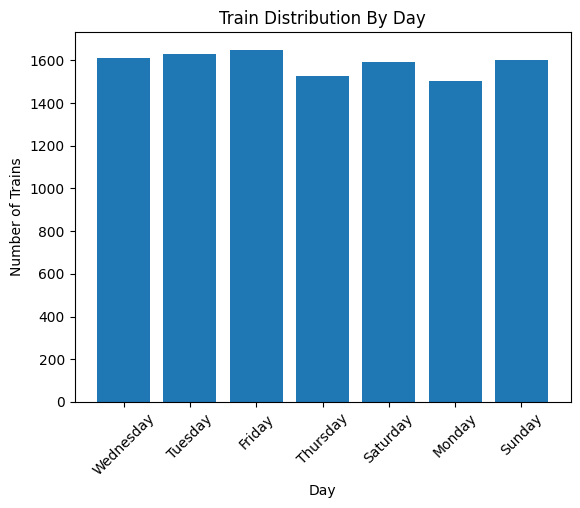

In [128]:
plt.bar(data["days"],data["count"])
plt.xticks(rotation=45)
plt.xlabel("Day")
plt.ylabel("Number of Trains")
plt.title("Train Distribution By Day")
plt.show()

#4.2 : Raiway Data Analysis Report

Railway Data Analysis Report

Overview

This project analyzes railway train operation data using PySpark. The dataset contains information about train numbers, train names, source stations, destination stations, and operating days. The objective was to perform data exploration, cleaning, transformation, aggregation, analysis, and visualization to gain useful insights.

Data Exploration

- Total number of train records: 11,113
- Unique source stations: 921
- Unique destination stations: 924
- The dataset contains train details, source station names, destination station names, and operating days.

Data Cleaning

- Checked for missing values in all columns.
- No missing values were found in the dataset.
- Standardized station names by converting them to uppercase.
- Removed extra spaces from the operating day column for accurate analysis.

Data Transformation and Aggregation

Data Filtering

- Extracted trains operating on Saturdays.
- Created a separate dataset for trains originating from Chennai Central station.

Grouping and Aggregation

- Counted the number of trains originating from each source station.
- Identified major source stations with high train traffic.

Data Enrichment

- Added a new column named "Category".
- Classified trains as:
  - Weekend: Saturday and Sunday
  - Weekday: Monday to Friday

Pattern Analysis

The distribution of trains across different days of the week was analyzed.

Day| Number of Trains
Friday| 1649
Tuesday| 1628
Wednesday| 1612
Sunday| 1602
Saturday| 1593
Thursday| 1526
Monday| 1503

Correlation and Insights

Key Findings

- Friday has the highest number of train operations (1649).
- Monday has the lowest number of train operations (1503).
- Train operations are distributed fairly evenly throughout the week.
- No strong dependency was observed between train frequency and a specific day.

Recommendations

- Allocate additional operational resources on Fridays and Tuesdays due to higher train traffic.
- Maintain the current scheduling strategy because train operations are well balanced across the week.
- Monitor lower-traffic days such as Monday for possible optimization opportunities.

Visualization

A bar chart was created to visualize the distribution of trains across different days of the week. The visualization confirms that train frequencies remain relatively consistent throughout the week, with slight variations.

Conclusion

The railway dataset was successfully analyzed using PySpark. Data cleaning, filtering, aggregation, enrichment, and visualization techniques were applied to derive meaningful insights. The analysis revealed a balanced distribution of train operations across the week, with Friday showing the highest train activity and Monday showing the lowest.